In [1]:
from math import exp
import numpy as np
import matplotlib.pyplot as plt
from operator import attrgetter

# Nonstationary Bandit Environment

Bandit algorithms have proven effective for sequential decision-making problems with exploration-exploitation trade-offs. However, traditional bandit algorithms may not adequately handle complex scenarios such as non-stationary environments. This notebook examines bandit algorithms in a non-stationary setting.

We start by briefly describing how the rewards are generated:

- In each bandit environment, there are 5 arms and a total of $T=200$ decision-times.
- The mean rewards for each action $a \in [0 \colon 4]$, denoted $\{ \mu_{t,a} \}_{t=1}^T$, are sampled according to a Gaussian process.
- At decision time $t$, if action $A_t$ is selected, the reward $X_t$ is revealed, where $X_t = \mu_{t,A_t} + \epsilon_t$ for independent standard Gaussian noise ($\epsilon_1, \epsilon_2, \dots, \epsilon_T \overset{\text{i.i.d.}}{\sim} N(0,1)$).

In [2]:
# Gaussian Process with Radial Basis Function Kernel
def rbf_kernel(x1, x2, variance = 1):
    return exp(-1 * ((x1-x2) ** 2) / (2*variance))

def gram_matrix(xs,var):
    return [[rbf_kernel(x1,x2,variance=var) for x2 in xs] for x1 in xs]

def generate_mean_rewards(n_arms=5,smoothness=1):
    xs = np.arange(0, 5, 0.025)
    mean = [0 for x in xs]
    gram = gram_matrix(xs, var=smoothness)
        
    all_mean_rewards = []
    for i in range(n_arms):
        mus = np.random.multivariate_normal(mean, gram)
        all_mean_rewards.append(mus)
    return np.vstack(all_mean_rewards)

def generate_rewards(mean_rewards, noise_var=1):
    rewards = mean_rewards + np.random.normal(0,np.sqrt(noise_var),size=mean_rewards.shape)
    return rewards

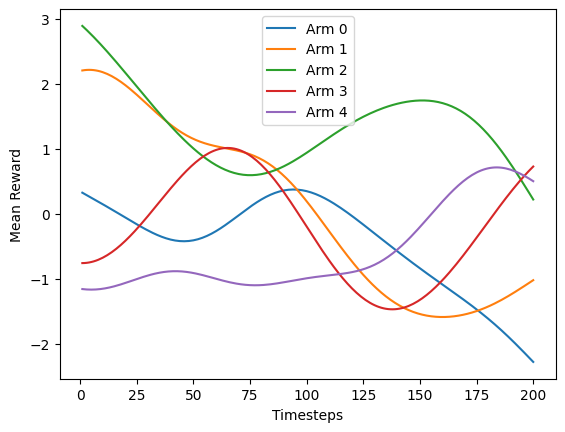

In [3]:
# Examining the Nonstationary Environment
mean_rewards = generate_mean_rewards(smoothness=1)
plt.figure()
for k in range(len(mean_rewards)):
    plt.plot(np.arange(1,len(mean_rewards[k])+1), mean_rewards[k], label='Arm {}'.format(k))
plt.ylabel('Mean Reward')
plt.xlabel('Timesteps')
plt.legend()
plt.show()

In [4]:
# Generating Rewards
rewards = generate_rewards(mean_rewards, noise_var=1)

I will first implement the following bandit algorithms in this environment and plot their regret. These will serve as the baseline algorithms.

- UCB
- Thompson sampling
- Uniform sampling

Since this is a nonstationary environment, I will use the expected dynamic regret. That is,

$$
\sum_{t=1}^T \text{max}_{a \in \mathcal{A}} ~ \mu_{t,a} - \mathbb{E} \left[ \sum_{t=1}^T X_t \right].
$$

For UCB, the upper confidence bound for each arm was initialised as $1000$. For Thompson sampling, the prior distribution for each arm was initialised as $N (0, 10)$.

In [5]:
# Simplify and adapt the Arm class and GetArms function to be suitable for this environment
class Arm:
    def __init__(self, index, mu_t_a, sigma):
        self.index = index
        self.numplays = 0.0
        self.mu_t_a = mu_t_a
        self.sigma = sigma
        self.totrew = 0.0
        self.avgrew = 0.0

    def sample(self, t):
        return self.mu_t_a[t] + np.random.normal(0, np.sqrt(1))

    def update(self, rew):
        self.numplays += 1
        self.totrew += rew
        self.avgrew = self.totrew / self.numplays

    def play(self, t):
        rew = self.sample(t)
        self.update(rew)
        return rew

def GetArms(K, mu_t, sigma):
    arms = []
    for i in range(K):
        arms.append(Arm(i, mu_t[i], sigma))
    return arms

In [6]:
def UpdateCBs(arm, T, K):
    cb = np.sqrt(2 * arm.sigma * (np.log(T * K)) / arm.numplays)
    arm.ucb = arm.avgrew + cb
    arm.lcb = arm.avgrew - cb

def UpperConfidenceBound(arms, T):
    t = 0
    rew = np.zeros(T)
    reg = np.zeros(T)
    K = len(arms)

    for arm in arms:
        rew[t] = arm.play(t)
        reg[t] = max(arm.mu_t_a[t] for arm in arms) - arm.mu_t_a[t]
        UpdateCBs(arm, T, K)
        t += 1
        if t == T:
            break

    while t < T:
        arm = max(arms, key=attrgetter('ucb'))
        rew[t] = arm.play(t)
        reg[t] = max(arm_2.mu_t_a[t] for arm_2 in arms) - arm.mu_t_a[t]
        UpdateCBs(arm, T, K)
        t += 1

    return rew, reg

In [7]:
def ThompsonSampling_Gaussian(arms, priors, T):
    t = 0
    rew = np.zeros(T)
    reg = np.zeros(T)
    K = len(arms)
    Gaussian_params = np.zeros((T, K, 2))

    posterior = 1.0*priors

    while t < T:
        thompson_samples = np.zeros(K)
        for myarm in arms:
            thompson_samples[myarm.index] = np.random.normal(posterior[myarm.index, 0],
                                                             np.sqrt(posterior[myarm.index, 1]))
        
        best_index = np.argmax(thompson_samples)
        arm = arms[best_index]
        rew[t] = arm.play(t)
        reg[t] = max([myarm.mu_t_a[t] for myarm in arms]) - arm.mu_t_a[t]

        mu_0 = posterior[best_index, 0]
        sigma2_0 = posterior[best_index, 1]
        sigma2 = arm.sigma
        posterior[best_index] = [((mu_0 / sigma2_0) + rew[t] / sigma2) / ((1 / sigma2) + 1 / sigma2_0),
                                 1 / ((1 / sigma2) + 1 / sigma2_0)]

        Gaussian_params[t] = posterior
        t += 1

    return rew, reg, Gaussian_params

In [8]:
def UniformSampling(arms, T):
    t = 0
    rew = np.zeros(T)
    reg = np.zeros(T)
    K = len(arms)

    while t < T:
        arm = np.random.choice(arms)
        rew[t] = arm.play(t)
        reg[t] = max(myarm.mu_t_a[t] for myarm in arms) - arm.mu_t_a[t]
        
        t += 1

    return rew, reg

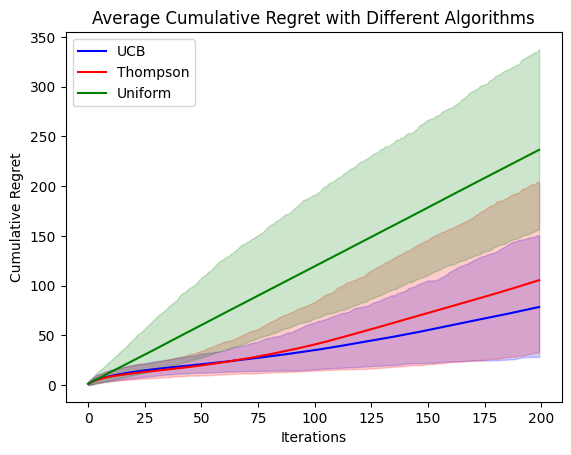

In [9]:
T, K, sigma = 200, 5, 1

regrets = np.zeros((1000, T))
for sim in range(1000):
    mean_rewards = generate_mean_rewards()
    bandits_env = GetArms(K, mean_rewards, sigma)
    for arm in bandits_env:
        setattr(arm, 'ucb', 1000.0)
        setattr(arm, 'lcb', -1000.0)
    regrets[sim] = np.cumsum(UpperConfidenceBound(bandits_env, T)[1])
mean_regrets = np.mean(regrets, axis=0)
sorted_regrets = np.sort(regrets, axis=0)
CB95 = sorted_regrets[949]
CB5 = sorted_regrets[49]
plt.plot(mean_regrets, label='UCB', color='b')
plt.fill_between(np.arange(T), CB5, CB95, alpha=0.2, color='b')

regrets = np.zeros((1000, T))
standard_priors = np.tile(np.array([0, 10]), (K, 1))
for sim in range(1000):
    mean_rewards = generate_mean_rewards()
    bandits_env = GetArms(K, mean_rewards, sigma)
    regrets[sim] = np.cumsum(ThompsonSampling_Gaussian(bandits_env, standard_priors, T)[1])
mean_regrets = np.mean(regrets, axis=0)
sorted_regrets = np.sort(regrets, axis=0)
CB95 = sorted_regrets[949]
CB5 = sorted_regrets[49]
plt.plot(mean_regrets, label='Thompson', color='r')
plt.fill_between(np.arange(T), CB5, CB95, alpha=0.2, color='r')

regrets = np.zeros((1000, T))
for sim in range(1000):
    mean_rewards = generate_mean_rewards()
    bandits_env = GetArms(K, mean_rewards, sigma)
    regrets[sim] = np.cumsum(UniformSampling(bandits_env, T)[1])
mean_regrets = np.mean(regrets, axis=0)
sorted_regrets = np.sort(regrets, axis=0)
CB95 = sorted_regrets[949]
CB5 = sorted_regrets[49]
plt.plot(mean_regrets, label='Uniform', color='g')
plt.fill_between(np.arange(T), CB5, CB95, alpha=0.2, color='g')

plt.legend(loc='upper left')
plt.xlabel('Iterations')
plt.ylabel('Cumulative Regret')
plt.title('Average Cumulative Regret with Different Algorithms')

It is clear that UCB performs better than Thompson sampling. The mean cumulative regret for UCB follows a relatively steady curve, which is marginally increasing. Furthermore, the $90\%$ confidence interval is relatively small. Conversely, the mean cumulative regret for Thompson sampling follows a less steady curve, which is sharply increasing. Furthermore, although the lower confidence interval is similar to that of UCB, the upper confidence interval is significantly higher.

Finally, uniform sampling performs the worst. It is reassuring to see that the mean cumulative regret follows a straight line. This is expected from uniform sampling: the sampling behaviour does not change over time.

I will now vary the sub-Gaussian parameter $\sigma$ in my implementation of UCB. In my first experiment, I take extreme values of $\sigma$ and observe the effect on cumulative regret over time.

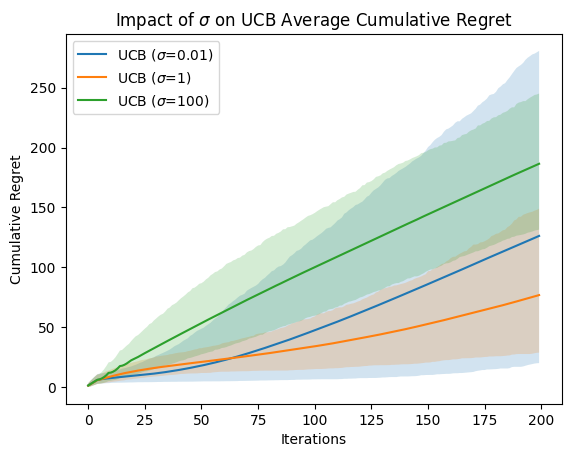

In [10]:
T, K = 200, 5
sigmas = [0.01, 1, 100]

for sigma in sigmas:
    regrets = np.zeros((1000, T))
    for sim in range(1000):
        mean_rewards = generate_mean_rewards()
        bandits_env = GetArms(K, mean_rewards, sigma)
        for arm in bandits_env:
            setattr(arm, 'ucb', 1000.0)
            setattr(arm, 'lcb', -1000.0)
        regrets[sim] = np.cumsum(UpperConfidenceBound(bandits_env, T)[1])
    mean_regrets = np.mean(regrets, axis=0)
    sorted_regrets = np.sort(regrets, axis=0)
    CB95 = sorted_regrets[949]
    CB5 = sorted_regrets[49]
    plt.plot(mean_regrets, label=rf'UCB ($\sigma$={sigma})')
    plt.fill_between(np.arange(T), CB5, CB95, alpha=0.2)

plt.legend(loc='upper left')
plt.xlabel('Iterations')
plt.ylabel('Cumulative Regret')
plt.title(r'Impact of $\sigma$ on UCB Average Cumulative Regret')

It is clear that taking extreme values of $\sigma$ causes the UCB algorithm to perform poorly.

When $\sigma$ is very small, the algorithm prioritises exploitation over exploration. This means that the performance of the algorithm is heavily dependent on the selection at the first time step. Furthermore, even if the algorithm selects the optimal action at the first time step, it will not adapt if the optimal action changes over time.

When $\sigma$ is very large, the algorithm prioritises exploration over exploitation. This means that the algorithm's sampling behaviour does not change much over time. Indeed, in the limit of large $\sigma$, I would posit that the UCB algorithm is the same as uniform sampling (see the bottom of this notebook).

In my second experiment, I take several intermediate values of $\sigma$ and observe the effect on cumulative regret at time step $200$.

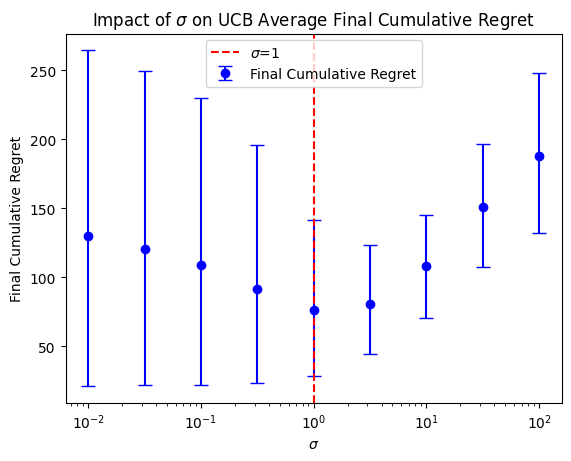

In [11]:
T, K = 200, 5
sigmas = np.logspace(-2, 2, num=9)
final_mean_regrets = []
upper_bounds = []
lower_bounds = []

for sigma in sigmas:
    regrets = np.zeros((1000, T))
    for sim in range(1000):
        mean_rewards = generate_mean_rewards()
        bandits_env = GetArms(K, mean_rewards, sigma)
        for arm in bandits_env:
            setattr(arm, 'ucb', 1000.0)
            setattr(arm, 'lcb', -1000.0)
        regrets[sim] = np.cumsum(UpperConfidenceBound(bandits_env, T)[1])
    # Compute final cumulative regret at the last time point
    final_regrets = regrets[:, -1]
    mean_final_regret = np.mean(final_regrets)
    sorted_final_regrets = np.sort(final_regrets)
    CB95 = sorted_final_regrets[949]
    CB5 = sorted_final_regrets[49]
    final_mean_regrets.append(mean_final_regret)
    upper_bounds.append(CB95)
    lower_bounds.append(CB5)

plt.errorbar(sigmas, final_mean_regrets, 
             yerr=[np.array(final_mean_regrets) - np.array(lower_bounds), 
                   np.array(upper_bounds) - np.array(final_mean_regrets)], 
             fmt='o', capsize=5, color='b', label='Final Cumulative Regret')

# Add a line at sigma = 1
plt.axvline(x=1.0, linestyle='--', color='r', label=r'$\sigma$=1')

plt.xscale('log')
plt.xlabel(r'$\sigma$')
plt.ylabel('Final Cumulative Regret')
plt.title(r'Impact of $\sigma$ on UCB Average Final Cumulative Regret')
plt.legend()

The average final cumulative regret of the UCB algorithm is minimised when $\sigma=1$. This is to be expected since it is the true value.

As $\sigma$ decreases, the algorithm becomes increasingly dependent on the selections at the first time steps. The nonstationary bandit environment changes from one simulation to the next. Generating a new set of mean rewards and replotting (i.e. rerunning code cell 3) shows that the best / worst action sometimes remains constant throughout. As a result, the size of the confidence interval increases as $\sigma$ decreases.

As $\sigma$ increases, the average final cumulative regret increases and the size of the confidence interval remains fairly constant.

Consider the Rexp3 algorithm presented in [Besbes et al. (2014)](https://proceedings.neurips.cc/paper_files/paper/2014/file/91ba7292e5388b90b58d0b839a7f19ec-Paper.pdf).

**Precise mathematical description**

1. **Batch setup:** The time horizon $T$ is divided into batches of size $\Delta_T$. Within each batch, the Exp3 method is applied to adjust the weight of each arm based on observed rewards.
2. **Initialisation:** For each batch, weight is initialised as $w_k = 1$ for each arm $k \in \{1, \ldots, K\}$.
3. **Arm selection:** At time $t$, the probability $p_k$ of selecting arm $k$ is computed as
   $$
   p_k = (1 - \gamma) \frac{w_k}{\sum_{k'=1}^{K} w_{k'}} + \frac{\gamma}{K},
   $$
   where $\gamma \in (0, 1]$ is a hyperparameter that controls the exploration-exploitation trade-off.
4. **Reward adjustment:** When arm $k'$ is selected at time $t$ and yields reward $X_{k'}$, the adjusted reward $\hat{X}_{k}$ for each arm $k$ is computed as
   $$
   \hat{X}_{k} = \frac{X_{k}}{p_{k}} \text{ for } k = k', \quad \hat{X}_k = 0 \text{ for } k \neq k'.
   $$
5. **Weight update:** The weight for each arm $k$ is updated as
   $$
   w_k \leftarrow w_k \exp \left( \frac{\gamma \hat{X}_k}{K} \right).
   $$
6. **Batch reset:** At the end of each batch, the weight for each arm is reset.

**Intuitive description**

There are three key aspects of the Rexp3 algorithm.

1. **Batching:** [Steps 1 and 6 above] Rexp3 divides the time horizon into batches and restarts the learning process at the start of each batch. This approach addresses the issue of nonstationarity, as older information may become misleading in an environment where reward distributions change over time.
2. **Exploration-exploitation trade-off:** [Step 3 above] Within each batch, Rexp3 employs the Exp3 method. This method is designed to balance exploration with exploitation, controlled by a hyperparameter that can be set accordingly. At this point it is worth noting that setting $\gamma=1$ renders the Rexp3 algorithm the same as uniform sampling.
3. **Weight update using exponential scaling:** [Steps 4 and 5 above] Rexp3 assigns weights to arms based on their past rewards, exponentially updating these weights to favour arms that perform best within each batch.

I will now implement the Rexp3 algorithm.

In [12]:
# Paper at https://proceedings.neurips.cc/paper_files/paper/2014/file/91ba7292e5388b90b58d0b839a7f19ec-Paper.pdf
def Rexp3(arms, T, gamma, delta_T):
    rew = np.zeros(T)
    reg = np.zeros(T)
    K = len(arms)
    # 1
    j = 1
    # 2
    while j <= np.ceil(T / delta_T):
        # 2 (a)
        tau = (j - 1) * delta_T
        # 2 (b)
        ws = np.ones(K)
        # 2 (c)
        for t in range(tau + 1, min(T, tau + delta_T) + 1):
            # 2 (c) i
            ps = (1 - gamma) * (ws / np.sum(ws)) + (gamma / K)
            # 2 (c) ii
            arm_index = np.random.choice(K, p=ps)
            arm = arms[arm_index]
            # 2 (c) iii
            # NOTE: We must use index t - 1 for consistency
            rew[t - 1] = arm.play(t - 1)
            reg[t - 1] = max(myarm.mu_t_a[t-1] for myarm in arms) - arm.mu_t_a[t-1]
            # 2 (c) iv
            adjusted_reward = rew[t - 1] / ps[arm_index]
            for k in range(K):
                if k == arm_index:
                    ws[k] *= np.exp(gamma * adjusted_reward / K)
                else:
                    ws[k] *= 1.0
        # 2 (d)
        j += 1
    return rew, reg

I take several values of $\Delta_T$ and observe the effect on cumulative regret over time. This serves the following two purposes. Firstly, it allows us to see better values of $\Delta_T$. Secondly, it allows us to compare the Rexp3 algorithm to the baseline algorithms.

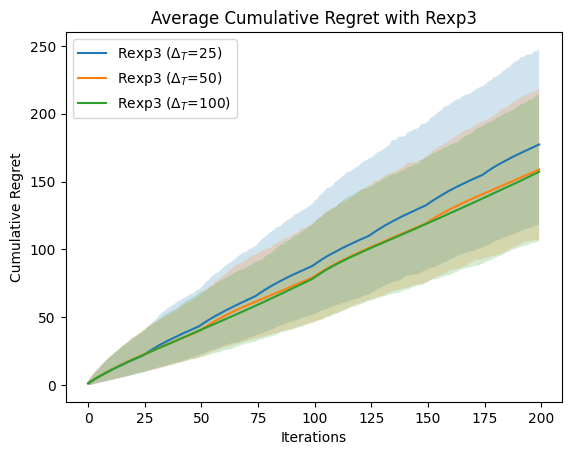

In [13]:
# Set parameters
T, K, sigma = 200, 5, 1
gamma = 0.5
delta_T_values = [25, 50, 100]

for delta_T in delta_T_values:
    regrets = np.zeros((1000, T))
    for sim in range(1000):
        mean_rewards = generate_mean_rewards()
        bandits_env = GetArms(K, mean_rewards, sigma)
        regrets[sim] = np.cumsum(Rexp3(bandits_env, T, gamma, delta_T)[1])
    mean_regrets_rexp3 = np.mean(regrets, axis=0)
    sorted_regrets_rexp3 = np.sort(regrets, axis=0)
    CB95_rexp3 = sorted_regrets_rexp3[949]
    CB5_rexp3 = sorted_regrets_rexp3[49]
    plt.plot(mean_regrets_rexp3, label=rf'Rexp3 ($\Delta_T$={delta_T})')
    plt.fill_between(np.arange(T), CB5_rexp3, CB95_rexp3, alpha=0.2)

plt.legend(loc='upper left')
plt.xlabel('Iterations')
plt.ylabel('Cumulative Regret')
plt.title('Average Cumulative Regret with Rexp3')

We see that $\Delta_T = 100$ produces the best results. This is not entirely surprising. Generating a new set of mean rewards and replotting (i.e. rerunning code cell 3) shows that the ranking of actions can remain constant for approximately $100$ decision times.

I previously posited that in the limit of large sub-Gaussian parameter $\sigma$, the UCB algorithm is the same as uniform sampling. This is further investigated below.

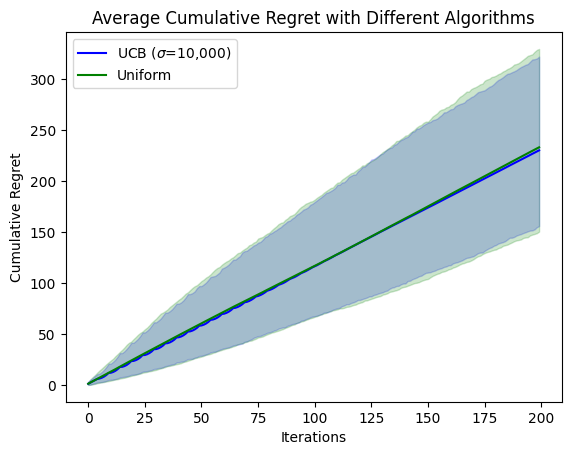

In [14]:
T, K, sigma = 200, 5, 10000

regrets = np.zeros((1000, T))
for sim in range(1000):
    mean_rewards = generate_mean_rewards()
    bandits_env = GetArms(K, mean_rewards, sigma)
    for arm in bandits_env:
        setattr(arm, 'ucb', 1000.0)
        setattr(arm, 'lcb', -1000.0)
    regrets[sim] = np.cumsum(UpperConfidenceBound(bandits_env, T)[1])
mean_regrets = np.mean(regrets, axis=0)
sorted_regrets = np.sort(regrets, axis=0)
CB95 = sorted_regrets[949]
CB5 = sorted_regrets[49]
plt.plot(mean_regrets, label=r'UCB ($\sigma$=10,000)', color='b')
plt.fill_between(np.arange(T), CB5, CB95, alpha=0.2, color='b')

regrets = np.zeros((1000, T))
for sim in range(1000):
    mean_rewards = generate_mean_rewards()
    bandits_env = GetArms(K, mean_rewards, sigma)
    regrets[sim] = np.cumsum(UniformSampling(bandits_env, T)[1])
mean_regrets = np.mean(regrets, axis=0)
sorted_regrets = np.sort(regrets, axis=0)
CB95 = sorted_regrets[949]
CB5 = sorted_regrets[49]
plt.plot(mean_regrets, label='Uniform', color='g')
plt.fill_between(np.arange(T), CB5, CB95, alpha=0.2, color='g')

plt.legend(loc='upper left')
plt.xlabel('Iterations')
plt.ylabel('Cumulative Regret')
plt.title('Average Cumulative Regret with Different Algorithms')

To conclude, I would recommend to use UCB for deployment. Although it is not designed for a nonstationary bandit environment, the results are the best.

However, if the environment changed and more decision times were introduced then my answer may change. If this were to happen, I would posit that the Rexp3 algorithm would be more suitable to use for deployment. This could be an avenue for future work.